 # ResearchLens LK — OpenAlex vs Crossref Metadata Enrichment Analysis (v4)




 ## 1. Imports & display settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)


 ## 2. Load data

In [3]:
OA_PATH = "../data/raw/open-alex/open_alex.csv"
CR_PATH = "../data/processed/crossref_clean_2016_2026_enriched.csv"

oa = pd.read_csv(OA_PATH, low_memory=False)
cr = pd.read_csv(CR_PATH, low_memory=False)

print("OpenAlex (raw):", oa.shape)
print("Crossref:", cr.shape)

oa = oa[oa["publication_year"] >= 2016].copy()
print("OpenAlex (2016+):", oa.shape)


OpenAlex (raw): (73289, 34)
Crossref: (65946, 55)
OpenAlex (2016+): (73289, 34)


In [4]:
oa.columns

Index(['openalex_id', 'doi', 'title', 'publication_year', 'publication_date', 'type', 'cited_by_count', 'author_count', 'authors',
       'sri_lankan_authors', 'institutions', 'sri_lankan_institutions', 'countries', 'source_name', 'publisher', 'is_oa', 'landing_page_url',
       'pdf_url', 'referenced_works_count', 'concepts', 'topics', 'primary_topic', 'primary_field', 'primary_subfield', 'primary_domain', 'language',
       'oa_status', 'license', 'source_type', 'issn_l', 'volume', 'issue', 'first_page', 'last_page'],
      dtype='str')

In [5]:
oa.columns
cr.columns

Index(['reference-count', 'publisher', 'issue', 'abstract', 'DOI', 'type', 'is-referenced-by-count', 'title', 'volume', 'container-title', 'URL',
       'ISSN', 'issued.date-parts', 'published.date-parts', 'created.date-parts', 'page', 'event.name', 'event.location', 'event.start.date-parts',
       'event.end.date-parts', 'language', 'article-number', 'publisher-location', 'event.acronym', 'group-title', 'subtype', 'event.sponsor',
       'original-title', 'subtitle', 'publication_year', 'author_given', 'author_family', 'author_name', 'author_affiliation', 'author_ORCID',
       'author_authenticated-orcid', 'author_sequence', 'author_role', 'editor_given', 'editor_family', 'editor_name', 'editor_affiliation',
       'editor_ORCID', 'editor_authenticated-orcid', 'editor_sequence', 'editor_role', 'funder_name', 'funder_DOI', 'funder_id', 'funder_award',
       'funder_doi-asserted-by', 'license_URL', 'license_content-version', 'license_delay-in-days', 'references_json'],
      dtype='s

 ## 3. Missing-value & coverage helpers



In [6]:
MISSING_TOKENS = {"", "nan", "null", "none", "[]", "{}"}


def is_missing(v):
    """True for real NaN and for stringified placeholders CSV exports use
    for empty lists/dicts ("nan", "[]", "{}", etc.). Does NOT treat boolean
    False as missing — see note above."""
    if pd.isna(v):
        return True
    return str(v).strip().lower() in MISSING_TOKENS


def coverage(df, column):
    """% of non-missing values for `column` in `df`. NaN if column/frame is empty."""
    if column is None or column not in df.columns or len(df) == 0:
        return np.nan
    present = df[column].apply(lambda x: not is_missing(x)).sum()
    return round((present / len(df)) * 100, 2)



 ## 4. Derived columns



 OpenAlex splits page numbers into `first_page`/`last_page`; Crossref uses

 a single `page` field ("123-145"). Build one presence flag on the

 OpenAlex side so the two compare like-for-like later.



 Stores True/NaN, not True/False — see the note in Section 3.

In [7]:
page_present = ~(oa["first_page"].apply(is_missing) & oa["last_page"].apply(is_missing))
oa["has_page_info"] = np.where(page_present, True, np.nan)


 ## 5. Field map




In [8]:
FIELD_MAP = {
    "oa_doi": "doi",
    "cr_doi": "DOI",
    "oa_abstract": None,  # OpenAlex export has no abstract field
    "cr_abstract": "abstract",
    "oa_orcid": None,  # OpenAlex export has no ORCID field
    "cr_orcid": "author_ORCID_any",  # created during Crossref aggregation, Section 9
    "oa_license": None,  # OpenAlex export has no license field
    "cr_license": "license_URL",
    "oa_article_number": None,  # OpenAlex export has no article-number field
    "cr_article_number": "article-number",
    "oa_container": "source_name",
    "cr_container": "container-title",
    "oa_issn": "journal_issn_l",
    "cr_issn": "ISSN",
    "oa_funder": "funders",
    "cr_funder": "funder_name_any",  # created during Crossref aggregation, Section 9
    "oa_reference": "referenced_works_count",
    "cr_reference": "reference-count",
    "oa_cited_by": "cited_by_count",
    "cr_cited_by": "is-referenced-by-count",
}
FIELD_MAP


{'oa_doi': 'doi',
 'cr_doi': 'DOI',
 'oa_abstract': None,
 'cr_abstract': 'abstract',
 'oa_orcid': None,
 'cr_orcid': 'author_ORCID_any',
 'oa_license': None,
 'cr_license': 'license_URL',
 'oa_article_number': None,
 'cr_article_number': 'article-number',
 'oa_container': 'source_name',
 'cr_container': 'container-title',
 'oa_issn': 'journal_issn_l',
 'cr_issn': 'ISSN',
 'oa_funder': 'funders',
 'cr_funder': 'funder_name_any',
 'oa_reference': 'referenced_works_count',
 'cr_reference': 'reference-count',
 'oa_cited_by': 'cited_by_count',
 'cr_cited_by': 'is-referenced-by-count'}

 ### Sanity check (optional)



In [9]:
def find_cols(df, keyword):
    return [c for c in df.columns if keyword.lower() in c.lower()]


for kw in [
    "doi",
    "abstract",
    "fund",
    "orcid",
    "license",
    "reference",
    "article",
    "issn",
    "volume",
    "issue",
    "container",
    "source",
    "event",
    "publisher",
    "cited",
    "referenced-by",
    "type",
]:
    print(f"{kw:10s} -> OA: {find_cols(oa, kw)}  |  CR: {find_cols(cr, kw)}")


doi        -> OA: ['doi']  |  CR: ['DOI', 'funder_DOI', 'funder_doi-asserted-by']
abstract   -> OA: []  |  CR: ['abstract']
fund       -> OA: []  |  CR: ['funder_name', 'funder_DOI', 'funder_id', 'funder_award', 'funder_doi-asserted-by']
orcid      -> OA: []  |  CR: ['author_ORCID', 'author_authenticated-orcid', 'editor_ORCID', 'editor_authenticated-orcid']
license    -> OA: ['license']  |  CR: ['license_URL', 'license_content-version', 'license_delay-in-days']
reference  -> OA: ['referenced_works_count']  |  CR: ['reference-count', 'is-referenced-by-count', 'references_json']
article    -> OA: []  |  CR: ['article-number']
issn       -> OA: ['issn_l']  |  CR: ['ISSN']
volume     -> OA: ['volume']  |  CR: ['volume']
issue      -> OA: ['issue']  |  CR: ['issue', 'issued.date-parts']
container  -> OA: []  |  CR: ['container-title']
source     -> OA: ['source_name', 'source_type']  |  CR: []
event      -> OA: []  |  CR: ['event.name', 'event.location', 'event.start.date-parts', 'event.end

 ## 6. Normalize DOIs

In [10]:
def normalize_doi(x):
    if pd.isna(x):
        return None
    x = str(x).strip().lower()
    x = x.replace("https://doi.org/", "").replace("http://doi.org/", "")
    return x


oa["doi_norm"] = oa[FIELD_MAP["oa_doi"]].apply(normalize_doi)
cr["doi_norm"] = cr[FIELD_MAP["cr_doi"]].apply(normalize_doi)

doi_stats = pd.DataFrame(
    {
        "Dataset": ["OpenAlex", "Crossref"],
        "Unique DOI": [oa["doi_norm"].nunique(), cr["doi_norm"].nunique()],
        "Missing DOI": [oa["doi_norm"].isna().sum(), cr["doi_norm"].isna().sum()],
    }
)
doi_stats


,Dataset,Unique DOI,Missing DOI
0,OpenAlex,71368,1889
1,Crossref,65946,0


 ## 7. DOI overlap + export the missing DOIs



In [11]:
oa_dois = set(oa["doi_norm"].dropna())
cr_dois = set(cr["doi_norm"].dropna())

common = oa_dois & cr_dois
oa_only = oa_dois - cr_dois
cr_only = cr_dois - oa_dois

print(f"Common DOIs:          {len(common):,}")
print(f"OpenAlex only:        {len(oa_only):,}")
print(f"Crossref only:        {len(cr_only):,}")
print(f"Overlap rate (of OA): {len(common) / len(oa_dois) * 100:.1f}%")



Common DOIs:          65,891
OpenAlex only:        5,477
Crossref only:        55
Overlap rate (of OA): 92.3%


In [12]:
oa_only_df = (
    oa[oa["doi_norm"].isin(oa_only)][["doi_norm", "title", "type", "publication_year"]]
    .drop_duplicates(subset="doi_norm")
    .copy()
)

EXPORT_PATH = "../data/processed/oa_only_dois_for_crossref_refetch.csv"
oa_only_df.to_csv(EXPORT_PATH, index=False)
print(f"Exported {len(oa_only_df):,} DOIs to {EXPORT_PATH}")


Exported 5,477 DOIs to ../data/processed/oa_only_dois_for_crossref_refetch.csv


 ## 8. Collapse Crossref to one row per DOI



In [13]:
oa_dup_count = oa["doi_norm"].duplicated().sum()
cr_dup_count = cr["doi_norm"].duplicated().sum()
print("OpenAlex duplicate DOI rows:", oa_dup_count)
print(
    "Crossref duplicate DOI rows:",
    cr_dup_count,
    f"({cr.shape[0]:,} raw rows -> {cr['doi_norm'].nunique():,} unique DOIs)",
)



OpenAlex duplicate DOI rows: 1920
Crossref duplicate DOI rows: 0 (65,946 raw rows -> 65,946 unique DOIs)


In [14]:
def clean_missing_tokens(df):
    """Replace all missing-token placeholders with real NaN across the whole
    frame, once, so groupby aggregations can use pandas' fast built-in
    first()/notna() instead of a slow per-group Python lambda."""
    cleaned = df.copy()
    for col in cleaned.columns:
        cleaned[col] = cleaned[col].where(~cleaned[col].apply(is_missing), np.nan)
    return cleaned


def aggregate_crossref(df, doi_col="doi_norm"):
    """Collapse a Crossref frame with possibly multiple rows per DOI into one
    row per DOI. Scalar/bibliographic columns take the first non-missing
    value; author_*/editor_*/funder_* columns become `{col}_any` (True if any
    row for this DOI was non-missing for that column, else NaN) plus a
    `row_count` column."""
    person_prefixes = ("author_", "editor_", "funder_")
    person_cols = [c for c in df.columns if c.startswith(person_prefixes)]
    scalar_cols = [c for c in df.columns if c not in person_cols and c != doi_col]

    g = df.groupby(doi_col)

    scalar_agg = g[scalar_cols].first()
    scalar_agg["row_count"] = g.size()

    person_summary = pd.DataFrame(index=scalar_agg.index)
    for col in person_cols:
        person_summary[f"{col}_any"] = g[col].apply(
            lambda s: True if s.notna().any() else np.nan
        )

    return scalar_agg.join(person_summary).reset_index()


cr_clean = clean_missing_tokens(cr)
cr_agg_all = aggregate_crossref(cr_clean, doi_col="doi_norm")

print("Crossref aggregated:", cr_agg_all.shape, "(one row per DOI)")
print("\nRaw rows collapsed per DOI (1 = no duplication):")
print(cr_agg_all["row_count"].value_counts().sort_index().head(10))


Crossref aggregated: (65946, 57) (one row per DOI)

Raw rows collapsed per DOI (1 = no duplication):
row_count
1    65946
Name: count, dtype: int64


 ## 9. Build the common-DOI merged dataset


In [15]:
oa_common = oa[oa["doi_norm"].isin(common)].drop_duplicates(subset="doi_norm").copy()
cr_common_agg = cr_agg_all[cr_agg_all["doi_norm"].isin(common)].copy()

merged = oa_common.merge(cr_common_agg, on="doi_norm", suffixes=("_oa", "_cr"))

print("Merged shape:", merged.shape, "| expected rows:", len(common))
assert len(merged) == len(common), (
    "Merge produced an unexpected row count — check for remaining duplicates"
)


Merged shape: (65891, 92) | expected rows: 65891


 ## 10. Column-resolution helpers




In [16]:
def resolve_merged_col(base_col, suffix):
    if base_col is None:
        return None
    if base_col + suffix in merged.columns:
        return base_col + suffix
    if base_col in merged.columns:
        return base_col
    return None


def overlap_table(oa_col_base, cr_col_base, label):
    """OA-only / CR-only / Both / Neither breakdown for a field pair, on `merged`."""
    oa_col = resolve_merged_col(oa_col_base, "_oa")
    cr_col = resolve_merged_col(cr_col_base, "_cr")
    if not oa_col or not cr_col:
        print(
            f"[{label}] column not found -> oa:{oa_col_base} cr:{cr_col_base} (skipped)"
        )
        return None

    oa_present = ~merged[oa_col].apply(is_missing)
    cr_present = ~merged[cr_col].apply(is_missing)

    table = pd.DataFrame(
        {
            "Category": ["OA only", "CR only (recoverable)", "Both", "Neither"],
            "Count": [
                int((oa_present & ~cr_present).sum()),
                int((~oa_present & cr_present).sum()),
                int((oa_present & cr_present).sum()),
                int((~oa_present & ~cr_present).sum()),
            ],
        }
    )
    table["% of common DOIs"] = round(table["Count"] / len(merged) * 100, 2)
    table.insert(0, "Field", label)
    return table


def field_report(df, col, label, scope_label):
    """Standalone coverage report for a field that only exists on one side."""
    if col is None or col not in df.columns:
        print(f"[{label}] column not found: {col}")
        return None
    present = int((~df[col].apply(is_missing)).sum())
    return {
        "Field": label,
        "Scope": scope_label,
        "Coverage %": coverage(df, col),
        "Records with data": present,
        "Total records": len(df),
    }



 ## 11. Type distribution & mapping

In [17]:
print("OpenAlex types:")
print(oa["type"].value_counts())

print("\nCrossref types:")
print(cr["type"].value_counts())


OpenAlex types:
type
article                    47202
conference-paper           11636
preprint                    4896
book-chapter                3050
report                      1554
conference-abstract         1118
review                       964
dataset                      792
other                        532
peer-review                  231
erratum                      205
editorial                    194
reference-entry              188
book                         178
paratext                     176
book-review                  102
software                      98
dissertation                  49
data-paper                    44
letter                        40
retraction                    21
supplementary-materials       17
software-paper                 2
Name: count, dtype: int64

Crossref types:
type
journal-article        48009
proceedings-article     9496
book-chapter            4267
posted-content          3322
peer-review              229
other                    17

In [18]:
TYPE_MAP = {
    # journal articles
    "article": "journal-article",  # OpenAlex
    "journal-article": "journal-article",  # Crossref
    # conference papers — OA and CR use different vocab, both map here
    "conference-paper": "conference-paper",  # OpenAlex
    "proceedings-article": "conference-paper",  # Crossref
    "conference-abstract": "conference-paper",
    # books
    "book-chapter": "book-chapter",
    "book": "book",
    "reference-book": "book",
    "monograph": "book",
    "edited-book": "book-chapter",
    # preprints
    "preprint": "preprint",
    "posted-content": "preprint",  # Crossref's preprint label
    # everything else — identity mapping, kept explicit rather than falling
    # through to NaN and silently dropping out of type-based analysis
    "review": "review",
    "peer-review": "peer-review",
    "report": "report",
    "dataset": "dataset",
    "letter": "letter",
    "editorial": "editorial",
    "software": "software",
    "reference-entry": "reference-entry",
    "erratum": "erratum",
    "paratext": "paratext",
    "dissertation": "dissertation",
    "retraction": "retraction",
    "other": "other",
    "journal-issue": "journal-issue",  # Crossref: a whole issue, not an article
}

oa["type_group"] = oa["type"].map(TYPE_MAP)
cr_agg_all["type_group"] = cr_agg_all["type"].map(TYPE_MAP)

unmapped_oa = oa.loc[oa["type_group"].isna() & oa["type"].notna(), "type"].unique()
unmapped_cr = cr_agg_all.loc[
    cr_agg_all["type_group"].isna() & cr_agg_all["type"].notna(), "type"
].unique()
if len(unmapped_oa) or len(unmapped_cr):
    print("Unmapped type values (add to TYPE_MAP if these matter):")
    print("  OA:", list(unmapped_oa))
    print("  CR:", list(unmapped_cr))


Unmapped type values (add to TYPE_MAP if these matter):
  OA: ['data-paper', 'book-review', 'supplementary-materials', 'software-paper']
  CR: ['book-section', 'component']


 ## 12. Journal metadata completeness (OA vs CR)




In [19]:
journal_field_candidates = {
    "volume": ("volume", "volume"),
    "issue": ("issue", "issue"),
    "page": ("has_page_info", "page"),
    "journal/container name": (FIELD_MAP["oa_container"], FIELD_MAP["cr_container"]),
    "ISSN": (FIELD_MAP["oa_issn"], FIELD_MAP["cr_issn"]),
}

journal_oa = oa[oa["type_group"] == "journal-article"]
journal_cr = cr_agg_all[cr_agg_all["type_group"] == "journal-article"]

rows = []
for label, (oa_col, cr_col) in journal_field_candidates.items():
    rows.append(
        {
            "field": label,
            "oa_coverage_%": coverage(journal_oa, oa_col),
            "cr_coverage_%": coverage(journal_cr, cr_col),
        }
    )

journal_comparison = pd.DataFrame(rows)
journal_comparison


,field,oa_coverage_%,cr_coverage_%
0,volume,91.44,92.70
1,issue,76.91,76.67
2,page,84.89,77.71
3,journal/container name,98.97,100.00
4,ISSN,NaN,99.57


 ## 13. Conference metadata completeness (OA vs CR)




In [20]:
conference_field_candidates = {
    "event name": (None, "event.name"),
    "publisher": ("publisher", "publisher"),
}

conference_oa = oa[oa["type_group"] == "conference-paper"]
conference_cr = cr_agg_all[cr_agg_all["type_group"] == "conference-paper"]

print(
    f"OA conference-paper rows: {len(conference_oa):,} | CR conference-paper rows: {len(conference_cr):,}"
)

rows = []
for label, (oa_col, cr_col) in conference_field_candidates.items():
    rows.append(
        {
            "field": label,
            "oa_coverage_%": coverage(conference_oa, oa_col),
            "cr_coverage_%": coverage(conference_cr, cr_col),
        }
    )

conference_comparison = pd.DataFrame(rows)
conference_comparison


OA conference-paper rows: 12,754 | CR conference-paper rows: 9,496


,field,oa_coverage_%,cr_coverage_%
0,event name,NaN,100.0
1,publisher,20.21,100.0


 ## 14. Crossref-exclusive fields: abstract, ORCID, license, article number



 

In [21]:
exclusive_fields = [
    ("abstract", FIELD_MAP["cr_abstract"]),
    ("ORCID (any author)", FIELD_MAP["cr_orcid"]),
    ("license", FIELD_MAP["cr_license"]),
    ("article number", FIELD_MAP["cr_article_number"]),
]

rows = []
for label, col in exclusive_fields:
    rows.append(field_report(cr_agg_all, col, label, "All Crossref DOIs"))
    cr_col_in_merged = resolve_merged_col(col, "_cr")
    rows.append(field_report(merged, cr_col_in_merged, label, "Common DOIs only"))

cr_exclusive_df = pd.DataFrame([r for r in rows if r])
cr_exclusive_df


,Field,Scope,Coverage %,Records with data,Total records
0,abstract,All Crossref DOIs,44.39,29275,65946
1,abstract,Common DOIs only,44.41,29263,65891
2,ORCID (any author),All Crossref DOIs,32.84,21659,65946
3,ORCID (any author),Common DOIs only,32.86,21649,65891
4,license,All Crossref DOIs,61.07,40275,65946
5,license,Common DOIs only,61.06,40232,65891
6,article number,All Crossref DOIs,15.39,10150,65946
7,article number,Common DOIs only,15.39,10143,65891


 ## 15. ISSN — is it actually a print/electronic pair?




In [22]:
issn_col = resolve_merged_col(FIELD_MAP["cr_issn"], "_cr")
sample_issn_values = merged[issn_col].dropna().head(15).tolist()
for v in sample_issn_values:
    print(v)


0306-3674; 1473-0480
2374-2437
0735-1097
1087-0792
1474-4422
['1364-0321']
0140-6736
2376-5992
0268-1161; 1460-2350
2374-2437
0017-9310
['0013-9351']
0045-6535
1461-023X; 1461-0248
2041-1723


 ## 16. Funder metadata — overlap on common DOIs




In [23]:
funder_overlap = overlap_table(FIELD_MAP["oa_funder"], FIELD_MAP["cr_funder"], "funder")
funder_overlap


[funder] column not found -> oa:funders cr:funder_name_any (skipped)


 ## 17. Reference-count coverage (magnitude, not presence)




In [24]:
oa_ref_col = resolve_merged_col(FIELD_MAP["oa_reference"], "_oa")
cr_ref_col = resolve_merged_col(FIELD_MAP["cr_reference"], "_cr")

ref_summary = pd.DataFrame(
    {
        "OpenAlex": merged[oa_ref_col].describe(),
        "Crossref": merged[cr_ref_col].describe(),
    }
)
print(ref_summary)

print("\n% of records with reference count == 0")
print("OpenAlex:", round((merged[oa_ref_col] == 0).mean() * 100, 2), "%")
print("Crossref:", round((merged[cr_ref_col] == 0).mean() * 100, 2), "%")


           OpenAlex      Crossref
count  65891.000000  65891.000000
mean      27.276457     27.438649
std       43.055269     49.299147
min        0.000000      0.000000
25%        0.000000      0.000000
50%       16.000000     14.000000
75%       38.000000     41.000000
max     3106.000000   3671.000000

% of records with reference count == 0
OpenAlex: 26.18 %
Crossref: 40.31 %


 ## 18. Citation-count divergence (BiasNote signal)




In [25]:
oa_cite_col = resolve_merged_col(FIELD_MAP["oa_cited_by"], "_oa")
cr_cite_col = resolve_merged_col(FIELD_MAP["cr_cited_by"], "_cr")

cite_df = merged[["doi_norm", oa_cite_col, cr_cite_col]].copy()
cite_df.columns = ["doi_norm", "oa_cited_by", "cr_referenced_by"]

cite_df["diff"] = cite_df["cr_referenced_by"] - cite_df["oa_cited_by"]
cite_df["abs_diff"] = cite_df["diff"].abs()
cite_df["ratio"] = np.where(
    cite_df["oa_cited_by"] > 0,
    cite_df["cr_referenced_by"] / cite_df["oa_cited_by"],
    np.nan,
)

print(cite_df[["oa_cited_by", "cr_referenced_by", "diff"]].describe())

SIGNIFICANT_ABS_DIFF = 10
SIGNIFICANT_RATIO = 1.5

cite_df["diverges"] = (cite_df["abs_diff"] >= SIGNIFICANT_ABS_DIFF) & (
    (cite_df["ratio"] >= SIGNIFICANT_RATIO)
    | (cite_df["ratio"] <= 1 / SIGNIFICANT_RATIO)
)

print(
    f"\nRecords with significant citation-count divergence: "
    f"{cite_df['diverges'].sum():,} ({cite_df['diverges'].mean() * 100:.1f}%)"
)

cite_df.sort_values("abs_diff", ascending=False).head(10)


        oa_cited_by  cr_referenced_by          diff
count  65891.000000      65891.000000  65891.000000
mean       9.716107          8.017058     -1.699048
std       66.413440         53.497265     17.735464
min        0.000000          0.000000  -3272.000000
25%        0.000000          0.000000     -1.000000
50%        1.000000          1.000000      0.000000
75%        6.000000          5.000000      0.000000
max    11215.000000       9432.000000    185.000000

Records with significant citation-count divergence: 1,034 (1.6%)


,doi_norm,oa_cited_by,cr_referenced_by,diff,abs_diff,ratio,diverges
1,10.1001/jamaoncol.2016.5688,6319,3047,-3272,3272,0.482197,True
0,10.1136/bjsports-2020-102955,11215,9432,-1783,1783,0.841016,False
17,10.1038/s41598-019-40613-7,1092,12,-1080,1080,0.010989,True
15,10.1371/journal.pone.0198166,1172,96,-1076,1076,0.081911,True
2,10.1016/j.jacc.2017.04.052,3883,3220,-663,663,0.829256,False
19,10.1136/bmj.m3379,1091,618,-473,473,0.566453,True
85,10.1038/s41598-019-56316-y,453,10,-443,443,0.022075,True
4,10.1016/s1474-4422(17)30299-5,2300,1878,-422,422,0.816522,False
9,10.1001/jamaoncol.2018.2706,1543,1186,-357,357,0.768633,False
134,10.4038/sljer.v7i2.119,347,1,-346,346,0.002882,True


 ## 19. Sri Lanka subset validation




In [26]:
print(
    oa["sri_lankan_authors"].dtype,
    "\n",
    oa["sri_lankan_authors"].value_counts(dropna=False).head(),
)
print(
    oa["sri_lankan_institutions"].dtype,
    "\n",
    oa["sri_lankan_institutions"].value_counts(dropna=False).head(),
)



str 
 sri_lankan_authors
LUNCHANAWAT NIMMAHNRATANAKUL     397
NIMMAHNRATANAKUL, LUNCHANAWAT    143
Meththika Vithanage              110
Candauda Arachchige Saliya       110
Ranil Fernando                   101
Name: count, dtype: int64
str 
 sri_lankan_institutions
University of Peradeniya             6125
University of Moratuwa               6085
University of Colombo                5325
University of Sri Jayewardenepura    4868
Department of Archaeology            3690
Name: count, dtype: int64


In [27]:
def is_sl_tagged(df):
    """True where sri_lankan_authors or sri_lankan_institutions indicates
    the record is SL-tagged. Boolean columns are checked for True
    specifically (False must NOT count as "tagged"); non-boolean
    (string/list-encoded) columns fall back to a non-missing check."""
    mask = pd.Series(False, index=df.index)
    for col in ["sri_lankan_authors", "sri_lankan_institutions"]:
        if col not in df.columns:
            continue
        series = df[col]
        non_null_values = set(series.dropna().unique().tolist())
        looks_boolean = series.dtype == bool or non_null_values <= {
            True,
            False,
            "True",
            "False",
        }
        if looks_boolean:
            mask = mask | series.fillna(False).astype(str).isin(["True", "1"])
        else:
            mask = mask | (~series.apply(is_missing))
    return mask


sl_mask = is_sl_tagged(merged)
sl_subset = merged[sl_mask].copy()
print(
    f"\nSri Lanka-tagged common-DOI records: {len(sl_subset):,} of {len(merged):,} "
    f"({len(sl_subset) / len(merged) * 100:.1f}%)"
)



Sri Lanka-tagged common-DOI records: 65,891 of 65,891 (100.0%)


In [28]:
sl_fields = [
    ("abstract", resolve_merged_col(FIELD_MAP["cr_abstract"], "_cr")),
    ("ORCID (any author)", resolve_merged_col(FIELD_MAP["cr_orcid"], "_cr")),
    ("license", resolve_merged_col(FIELD_MAP["cr_license"], "_cr")),
    ("article number", resolve_merged_col(FIELD_MAP["cr_article_number"], "_cr")),
    ("ISSN", resolve_merged_col(FIELD_MAP["cr_issn"], "_cr")),
]

sl_rows = [
    field_report(sl_subset, col, label, "Sri Lanka-tagged common DOIs")
    for label, col in sl_fields
]
sl_coverage_df = pd.DataFrame([r for r in sl_rows if r])
sl_coverage_df


,Field,Scope,Coverage %,Records with data,Total records
0,abstract,Sri Lanka-tagged common DOIs,44.41,29263,65891
1,ORCID (any author),Sri Lanka-tagged common DOIs,32.86,21649,65891
2,license,Sri Lanka-tagged common DOIs,61.06,40232,65891
3,article number,Sri Lanka-tagged common DOIs,15.39,10143,65891
4,ISSN,Sri Lanka-tagged common DOIs,76.44,50368,65891


In [29]:
sl_doi_set = set(sl_subset["doi_norm"])
sl_cite_divergence_rate = (
    cite_df[cite_df["doi_norm"].isin(sl_doi_set)]["diverges"].mean() * 100
)
print(
    f"Citation-count divergence rate, Sri Lanka subset: {sl_cite_divergence_rate:.1f}%"
)


Citation-count divergence rate, Sri Lanka subset: 1.6%


In [30]:
abstract_col = resolve_merged_col(FIELD_MAP["cr_abstract"], "_cr")
license_col = resolve_merged_col(FIELD_MAP["cr_license"], "_cr")

sample_n = min(50, len(sl_subset))
sl_sample = sl_subset.sample(sample_n, random_state=42)[
    ["doi_norm", abstract_col, license_col]
]

SL_SAMPLE_PATH = "../data/processed/sl_sample_50_for_manual_check.csv"
sl_sample.to_csv(SL_SAMPLE_PATH, index=False)
print(
    f"Saved {sample_n}-record Sri Lanka sample to {SL_SAMPLE_PATH} for manual inspection."
)


Saved 50-record Sri Lanka sample to ../data/processed/sl_sample_50_for_manual_check.csv for manual inspection.


 ## 20. Enrichment matrix — the table for your schema decision




In [31]:
enrichment_rows = []

paired_fields = {
    "volume": ("volume", "volume"),
    "issue": ("issue", "issue"),
    "page": ("has_page_info", "page"),
    "journal/container name": (FIELD_MAP["oa_container"], FIELD_MAP["cr_container"]),
    "ISSN": (FIELD_MAP["oa_issn"], FIELD_MAP["cr_issn"]),
    "funder": (FIELD_MAP["oa_funder"], FIELD_MAP["cr_funder"]),
}
for label, (oa_c, cr_c) in paired_fields.items():
    oa_r = resolve_merged_col(oa_c, "_oa")
    cr_r = resolve_merged_col(cr_c, "_cr")
    if not oa_r or not cr_r:
        continue
    oa_missing_mask = merged[oa_r].apply(is_missing)
    cr_present_mask = ~merged[cr_r].apply(is_missing)
    cr_only = int((oa_missing_mask & cr_present_mask).sum())
    enrichment_rows.append(
        {
            "Field": label,
            "OA coverage %": coverage(merged, oa_r),
            "CR coverage %": coverage(merged, cr_r),
            "CR-only records": cr_only,
            "Recommendation": "Keep" if cr_only > 0 else "Optional",
        }
    )

exclusive_fields_map = {
    "abstract": FIELD_MAP["cr_abstract"],
    "ORCID (any author)": FIELD_MAP["cr_orcid"],
    "license": FIELD_MAP["cr_license"],
    "article number": FIELD_MAP["cr_article_number"],
}
for label, cr_c in exclusive_fields_map.items():
    cr_r = resolve_merged_col(cr_c, "_cr")
    if not cr_r:
        continue
    cr_only = int((~merged[cr_r].apply(is_missing)).sum())
    enrichment_rows.append(
        {
            "Field": label,
            "OA coverage %": 0.0,
            "CR coverage %": coverage(merged, cr_r),
            "CR-only records": cr_only,
            "Recommendation": "Keep" if cr_only > 0 else "Optional",
        }
    )

enrichment_matrix = pd.DataFrame(enrichment_rows).sort_values(
    "CR-only records", ascending=False
)
enrichment_matrix


,Field,OA coverage %,CR coverage %,CR-only records,Recommendation
6,license,0.00,61.06,40232,Keep
4,abstract,0.00,44.41,29263,Keep
5,ORCID (any author),0.00,32.86,21649,Keep
3,journal/container name,82.98,94.32,10184,Keep
7,article number,0.00,15.39,10143,Keep
2,page,82.74,76.88,90,Keep
0,volume,70.81,67.81,34,Keep
1,issue,56.50,55.86,28,Keep


In [32]:
print(
    f"Citation-count divergence: {cite_df['diverges'].sum():,} of {len(cite_df):,} "
    f"common DOIs ({cite_df['diverges'].mean() * 100:.1f}%) — "
    "add oa_cited_by, cr_referenced_by, and a computed divergence flag to the schema."
)


Citation-count divergence: 1,034 of 65,891 common DOIs (1.6%) — add oa_cited_by, cr_referenced_by, and a computed divergence flag to the schema.


 ## 21. Overall metadata richness

In [33]:
def richness_score(df, sample=20000, random_state=42):
    data = (
        df.sample(sample, random_state=random_state)
        if sample and len(df) > sample
        else df
    )
    counts = data.apply(lambda row: sum(not is_missing(v) for v in row), axis=1)
    return {"Average": round(counts.mean(), 2), "Median": round(counts.median(), 2)}


print("OpenAlex richness:", richness_score(oa))
print("Crossref richness (aggregated):", richness_score(cr_agg_all))


OpenAlex richness: {'Average': np.float64(33.05), 'Median': np.float64(34.0)}
Crossref richness (aggregated): {'Average': np.float64(28.23), 'Median': np.float64(28.0)}


 ## 22. Visualization — coverage comparison

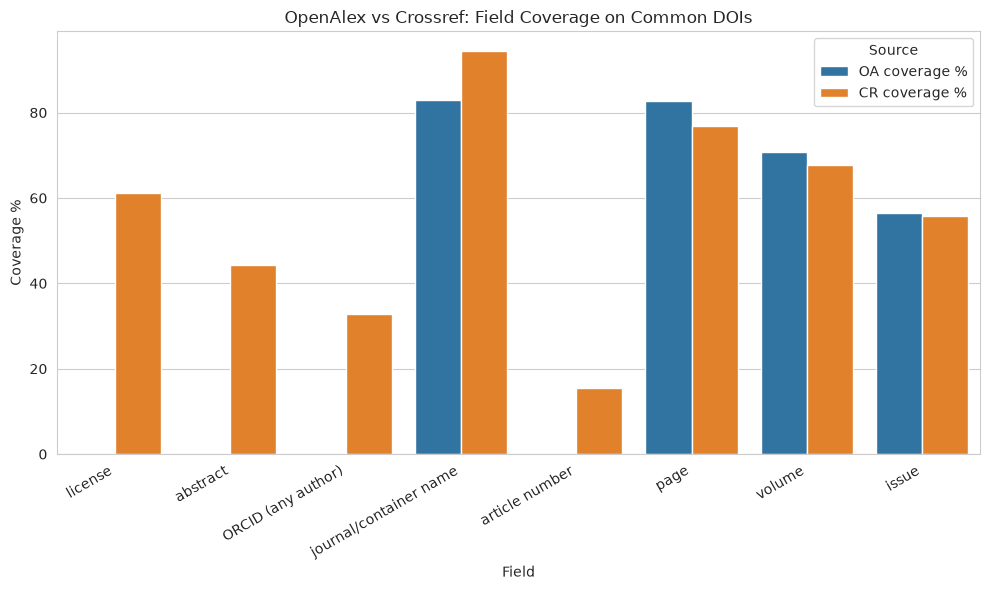

In [34]:
plot_df = enrichment_matrix.melt(
    id_vars="Field",
    value_vars=["OA coverage %", "CR coverage %"],
    var_name="Source",
    value_name="Coverage %",
)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="Field", y="Coverage %", hue="Source")
plt.xticks(rotation=30, ha="right")
plt.title("OpenAlex vs Crossref: Field Coverage on Common DOIs")
plt.tight_layout()
plt.show()


In [35]:
ref = merged[["doi_norm", "referenced_works_count", "reference-count"]].copy()

ref["diff"] = ref["reference-count"] - ref["referenced_works_count"]
ref["abs_diff"] = ref["diff"].abs()

print(ref[["referenced_works_count", "reference-count", "diff"]].describe())

print("Exact match %:", (ref["diff"] == 0).mean() * 100)

print(">5 diff %:", (ref["abs_diff"] > 5).mean() * 100)

print(">10 diff %:", (ref["abs_diff"] > 10).mean() * 100)


       referenced_works_count  reference-count          diff
count            65891.000000     65891.000000  65891.000000
mean                27.276457        27.438649      0.162192
std                 43.055269        49.299147     19.963653
min                  0.000000         0.000000   -808.000000
25%                  0.000000         0.000000     -1.000000
50%                 16.000000        14.000000      0.000000
75%                 38.000000        41.000000      4.000000
max               3106.000000      3671.000000   1126.000000
Exact match %: 31.39427235889575
>5 diff %: 36.7698168186854
>10 diff %: 23.025906421210788


In [36]:
oa_cov = merged["publisher_oa"].notna().mean() * 100
cr_cov = merged["publisher_cr"].notna().mean() * 100

print(oa_cov, cr_cov)



57.74384969115661 99.98634107844774


In [37]:
# uni=pd.read_csv("../data/raw/open-alex/repositories_combined.csv")
# print(uni.shape)
sljol = pd.read_csv("../data/raw/open-alex/sljol.csv")
print(sljol.shape)

(26200, 19)


In [38]:
print(sljol.columns)
print(sljol.isna().sum())

Index(['source_institution_id', 'source_record_id', 'source_datestamp', 'title', 'authors', 'contributors', 'abstract', 'keywords',
       'publication_date', 'publication_year', 'publication_type', 'publisher', 'journal', 'language', 'rights', 'doi', 'url', 'source_set_specs',
       'raw_identifiers'],
      dtype='str')
source_institution_id        0
source_record_id             0
source_datestamp             0
title                        4
authors                      4
contributors             26200
abstract                 12308
keywords                 26200
publication_date             0
publication_year             0
publication_type             0
publisher                    0
journal                      0
language                 26200
rights                   26200
doi                          0
url                          0
source_set_specs         26200
raw_identifiers              0
dtype: int64


In [39]:
sljol=sljol.drop(columns=["language","contributors","abstract","keywords","rights","source_set_specs"])


In [40]:
sljol.isna().sum()
print(sljol["publication_year"].value_counts())
sljol=sljol[sljol["publication_year"]>=2016]
print(sljol.shape)

publication_year
2025    2326
2021    2161
2022    2039
2023    1922
2024    1903
2020    1690
2017    1295
2018    1283
2016    1238
2015    1233
2019    1229
2009    1026
2014     985
2026     946
2011     889
2012     795
2013     782
2010     765
2008     325
2006     173
2007     173
2005     112
2003      94
2001      71
1998      58
2004      58
1997      58
1994      50
1992      49
2002      49
2000      49
1996      47
1999      43
1995      35
1983      31
1993      28
1984      27
1987      24
1989      21
1988      21
1986      21
1985      20
1991      19
1990      17
1982      13
1972       7
Name: count, dtype: int64
(18032, 13)


In [41]:
type=sljol["publication_type"].value_counts()
inst = sljol["publisher"].value_counts()
print(type)
print(inst)


publication_type
journal-article    18029
journal-issue          3
Name: count, dtype: int64
publisher
Sri Lanka Journals Online          9968
Sri Lanka Journals Online (JOL)    8064
Name: count, dtype: int64


In [43]:
issues=sljol[sljol["publication_type"]=="journal-issue"]
issues

,source_institution_id,source_record_id,source_datestamp,title,authors,publication_date,publication_year,publication_type,publisher,journal,doi,url,raw_identifiers
272,sljol,10.4038/pmr.v3i1,2024-08-23T09:24:52Z,NaN,NaN,2023-06-12,2023,journal-issue,Sri Lanka Journals Online,Peradeniya Management Review,10.4038/pmr.v3i1,https://doi.org/10.4038/pmr.v3i1,10.4038/pmr.v3i1; https://doi.org/10.4038/pmr....
10071,sljol,10.4038/pmr.v1i2,2025-11-25T06:23:45Z,NaN,NaN,2020-07-28,2020,journal-issue,Sri Lanka Journals Online,Peradeniya Management Review,10.4038/pmr.v1i2,https://doi.org/10.4038/pmr.v1i2,10.4038/pmr.v1i2; https://doi.org/10.4038/pmr....
26039,sljol,10.4038/pmr.v1i1,2025-11-25T06:12:23Z,NaN,NaN,2020-02-14,2020,journal-issue,Sri Lanka Journals Online,Peradeniya Management Review,10.4038/pmr.v1i1,https://doi.org/10.4038/pmr.v1i1,10.4038/pmr.v1i1; https://doi.org/10.4038/pmr....


In [56]:
sljol.columns

Index(['source_institution_id', 'source_record_id', 'source_datestamp', 'title', 'authors', 'publication_date', 'publication_year',
       'publication_type', 'publisher', 'journal', 'doi', 'url', 'raw_identifiers'],
      dtype='str')